<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/ml_python.png' width=600/></center>

<img src = "https://github.com/Jangrae/img/blob/master/medical2.png?raw=true" width=800 align="left"/>

# 실습 내용

- 다양한 알고리즘으로 성능이 최적화된 모델을 만듭니다.
- 성능이 좋을 것으로 예상되는 모델을 선정해 새로운 데이터에 대해 예측을 수행합니다.

# 1.환경 준비

- 기본 라이브러리와 대상 데이터를 가져와 이후 과정을 준비합니다.

In [2]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format = 'retina'

- 학습용 데이터를 불러옵니다.
- 평가용 데이터는 이후에 불러오게 됩니다.

In [4]:
# 학습용 데이터 불러오기
path = 'https://raw.githubusercontent.com/jangrae/csv/master/insurance_train.csv'
data = pd.read_csv(path)

# 2.데이터 이해

- 분석할 데이터를 충분히 이해할 수 있도록 다양한 탐색 과정을 수행합니다.

**데이터 설명**

- age: 나이
- sex: 성별(female, male)
- bmi: 체질량지수(체중을 키의 제곱으로 나눈 값, 적정수준:18.5 - 24.9)
- children: 자녀 수
- smoker: 흡연 여부
- region: 거주지역(northeast, southeast, southwest, northwest)
- **charges: 건강보험에서 지불한 의료비 - Target**

In [7]:
# 데이터 살펴보기
data

,age,sex,bmi,children,smoker,region,charges
0,41,female,31.600,0,no,southwest,6186.1270
1,30,male,25.460,0,no,northeast,3645.0894
2,18,female,30.115,0,no,northeast,21344.8467
3,61,female,29.920,3,yes,southeast,30942.1918
4,34,female,27.500,1,no,southwest,5003.8530
...,...,...,...,...,...,...,...
1233,50,male,30.970,3,no,northwest,10600.5483
1234,18,female,31.920,0,no,northeast,2205.9808
1235,18,female,36.850,0,no,southeast,1629.8335
1236,21,female,25.800,0,no,southwest,2007.9450


In [9]:
# 기술통계 확인
data.describe()

,age,bmi,children,charges
count,1238.000000,1238.000000,1238.000000,1238.000000
mean,39.236672,30.648522,1.096931,13164.000669
std,13.984795,6.129289,1.203057,11994.023291
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.220000,0.000000,4755.809850
50%,40.000000,30.305000,1.000000,9333.014350
75%,51.000000,34.496250,2.000000,16443.294663
max,64.000000,53.130000,5.000000,63770.428010


In [15]:
# 상관관계 
data.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.118700,0.042745,0.298278
bmi,0.118700,1.000000,0.010283,0.198830
children,0.042745,0.010283,1.000000,0.077073
charges,0.298278,0.198830,0.077073,1.000000


In [30]:
# Target 분포 확인
data['charges'].value_counts()

charges
1639.5631     2
6186.1270     1
6250.4350     1
2927.0647     1
6289.7549     1
             ..
2498.4144     1
11763.0009    1
11455.2800    1
3044.2133     1
29141.3603    1
Name: count, Length: 1237, dtype: int64

In [26]:
# 흡연자 비율
data['smoker'].value_counts()

smoker
no     991
yes    247
Name: count, dtype: int64

In [28]:
# 남녀 비율
data['sex'].value_counts()

sex
male      627
female    611
Name: count, dtype: int64

# 3.데이터 준비

- 전처리 과정을 통해 머신러닝 알고리즘에 사용할 수 있는 형태의 데이터를 준비합니다.

**1) x, y 분리**

In [32]:
# x, y 분리
target = 'charges'

x = data.drop(columns=target)
y = data[target]

**2) 가변수화**

In [34]:
# 가변수화
dumm_cols = ['sex', 'region', 'smoker']

x = pd.get_dummies(x, columns=dumm_cols, dtype=int, drop_first=True)

**3) 학습용, 평가용 데이터 분리**

In [62]:
# 학습용, 평가용 데이터 분리
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=1)

# 4.모델링

- 하이퍼파라미터 최적화 과정을 통해 최선의 성능을 갖는 모델을 만들고 성능을 검증합니다.
- 각 모델을 joblib.dump() 함수를 사용해 저장합니다.

In [51]:
# xgboost 설치
# !pip install xgboost

In [53]:
# lightgbm 설치
# !pip install lightgbm

- 이후 사용할 함수를 모두 불러옵니다.

In [95]:
# 불러오기
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import *
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
import joblib

**1) Linear Regression**

- Linear Regression 알고리즘으로 모델링하고 성능을 검증합니다.
- 모델을 파일로 저장힙니다.

In [65]:
# 모델링
model = LinearRegression()

# 학습하기
model.fit(x_train, y_train)

# 예측하기
y_val_pred = model.predict(x_val)

# 평가하기
print('MAE:', mean_absolute_error(y_val, y_val_pred))
print('R2:', r2_score(y_val, y_val_pred))

MAE: 4271.380933146249
R2: 0.7452192293600735


In [67]:
# 모델저장
joblib.dump(model, 'model_linear.pkl')

['model_linear.pkl']

**2) Decision Tree**

- 하이퍼파라미터 최적화 과정을 통해 최선의 성능을 갖는 Decision Tree 모델을 만들고 성능을 검증하세요.
- 변수 중요도를 시각화해 확인하고, 모델을 파일로 저장힙니다.

In [117]:
# 파라미터 선언
param = {'max_depth': range(1, 21)}

model = RandomizedSearchCV(DecisionTreeRegressor(),
                          param,
                          cv=5)

model.fit(x_train, y_train)
y_val_pred = model.predict(x_val)
print('MAE:', mean_absolute_error(y_val, y_val_pred))
print('R2:', r2_score(y_val, y_val_pred))

MAE: 2973.7554696468937
R2: 0.8577535714634761


<BarContainer object of 8 artists>

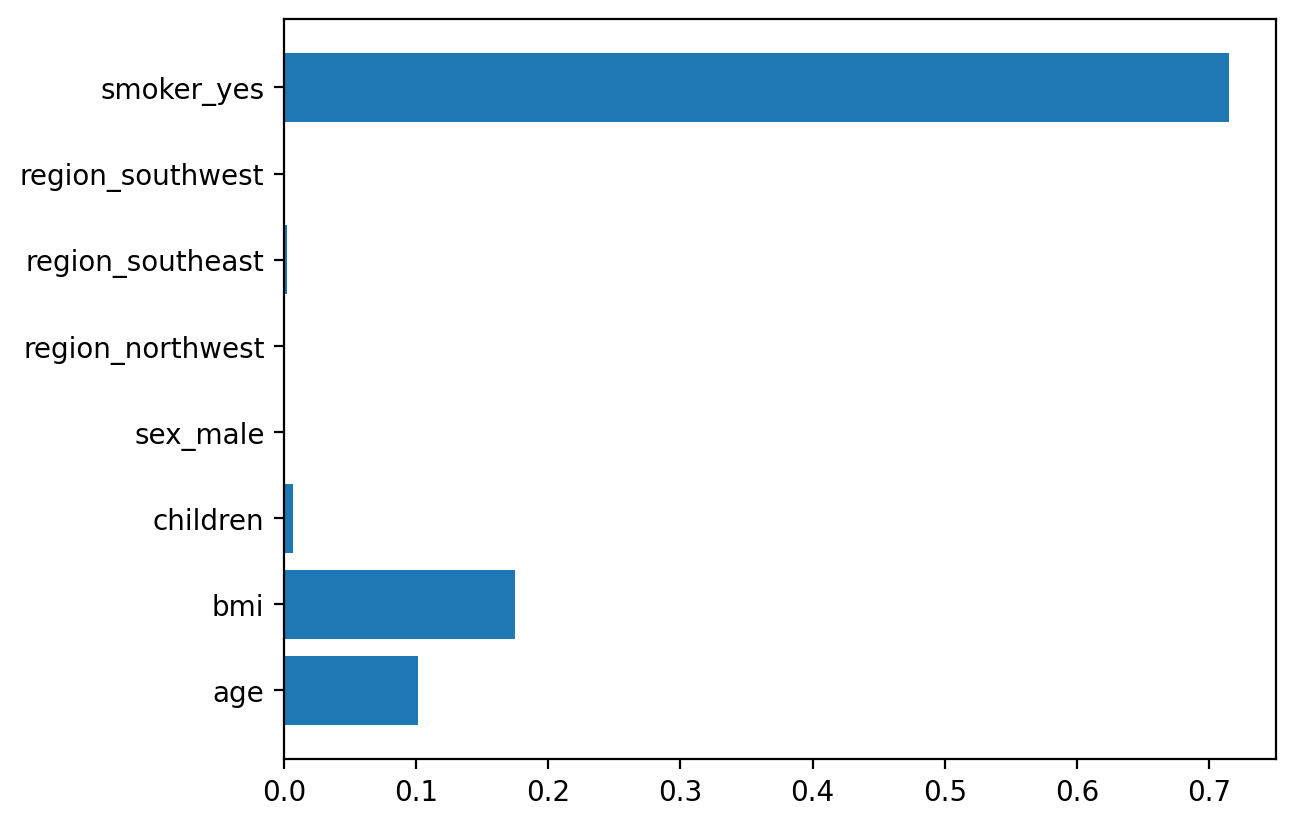

In [119]:
# 변수 중요도 시각화
plt.barh(list(x), model.best_estimator_.feature_importances_)

In [121]:
# 모델저장
joblib.dump(model, 'model_tree.pkl')

['model_tree.pkl']

**3) Random Forest**

- 하이퍼파라미터 최적화 과정을 통해 최선의 성능을 갖는 Random Forest 모델을 만들고 성능을 검증하세요.
- 변수 중요도를 시각화해 확인하고, 모델을 파일로 저장힙니다.

In [124]:
# 파라미터 선언
param = {'max_depth': range(1, 21)}

model = RandomizedSearchCV(RandomForestRegressor(),
                          param,
                          cv=5)

model.fit(x_train, y_train)
y_val_pred = model.predict(x_val)

# 평가하기
print('MAE:', mean_absolute_error(y_val, y_val_pred))
print('R2:', r2_score(y_val, y_val_pred))

MAE: 2737.0618706055566
R2: 0.867002827126131


<BarContainer object of 8 artists>

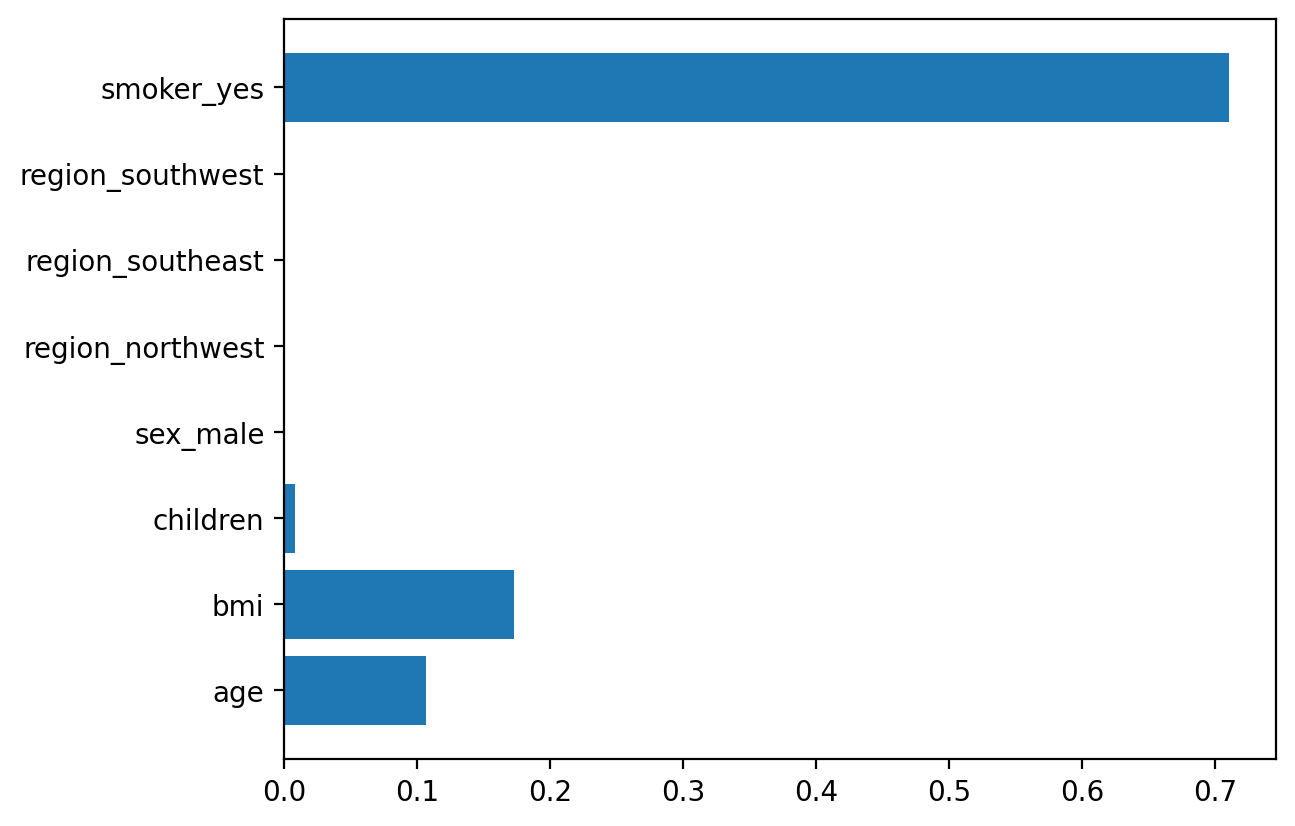

In [126]:
# 변수 중요도 시각화
plt.barh(list(x), model.best_estimator_.feature_importances_)

In [128]:
# 모델저장
joblib.dump(model, 'model_forest.pkl')

['model_forest.pkl']

**4) LightGBM**

- 하이퍼파라미터 최적화 과정을 통해 최선의 성능을 갖는 LightGBM 모델을 만들고 성능을 검증하세요.
- 변수 중요도를 시각화해 확인하고, 모델을 파일로 저장힙니다.

In [130]:
# 파라미터 선언
param = {'max_depth': range(1, 21)}

model = RandomizedSearchCV(RandomForestRegressor(),
                          param,
                          cv=5)

model.fit(x_train, y_train)
y_val_pred = model.predict(x_val)

# 평가하기
print('MAE:', mean_absolute_error(y_val, y_val_pred))
print('R2:', r2_score(y_val, y_val_pred))

MAE: 2649.5922291398197
R2: 0.8690970777951975


<BarContainer object of 8 artists>

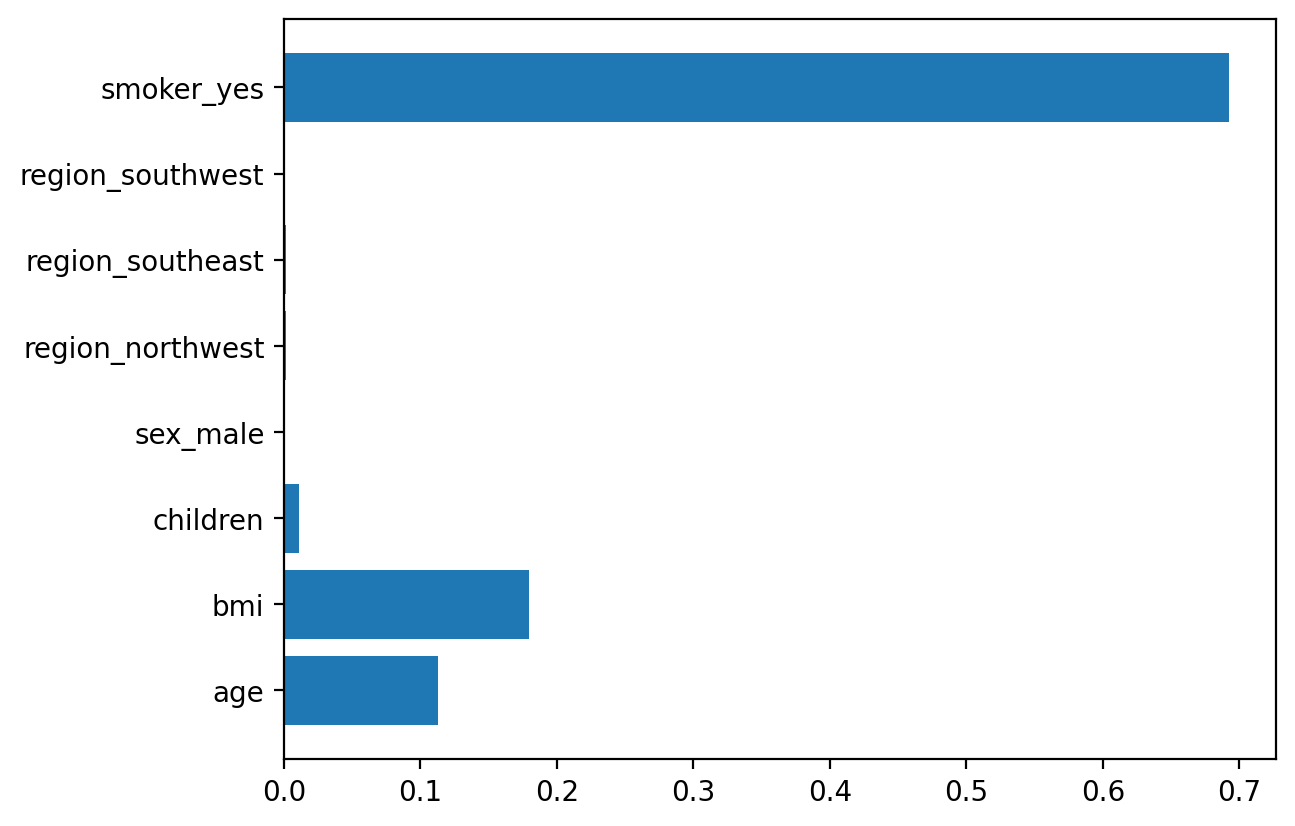

In [132]:
# 변수 중요도 시각화
plt.barh(list(x), model.best_estimator_.feature_importances_)

In [134]:
# 모델저장
joblib.dump(model, 'model_lgbm.pkl')

['model_lgbm.pkl']

# 5.성능평가

- 가장 좋은 성능을 보였던 모델을 joblib.load() 함수를 사용해 불러옵니다.
- 불러온 모델로 새로운 데이터에 대해 예측을 수행합니다.

In [136]:
# 모델 불러오기
model = joblib.load('model_lgbm.pkl')

In [138]:
# 평가용 데이터 불러오기
path = 'https://raw.githubusercontent.com/jangrae/csv/master/insurance_test.csv'
new_data = pd.read_csv(path)

# 확인
new_data.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


- 원본 데이터프레임을 유지하기 위해 새로운 데이터프레임으로 복사합니다.
- 복사된 데이터프레임에 대해 가변수화를 수행합니다.

In [148]:
# 데이터 복사
x_test = new_data.copy()

# 가변수화
dumm_cols = ['sex', 'region', 'smoker']
x_test = pd.get_dummies(x_test, columns=dumm_cols, drop_first=True, dtype=int)

# 확인
x_test.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
0,19,27.900,0,0,0,0,1,1
1,18,33.770,1,1,0,1,0,0
2,28,33.000,3,1,0,1,0,0
3,33,22.705,0,1,1,0,0,0
4,32,28.880,0,1,1,0,0,0


In [150]:
x_train.head()

,age,bmi,children,sex_male,region_northwest,region_southeast,region_southwest,smoker_yes
1094,31,21.755,0,0,1,0,0,0
538,39,26.410,0,1,0,0,0,1
200,36,27.550,3,1,0,0,0,0
927,23,18.715,0,1,1,0,0,0
1221,62,26.695,0,1,0,0,0,1


- 가변수화된 결과를 대상으로 예측을 수행합니다.
- 참고: 예측을 위해서는 모델이 학습했던 데이터(x_train)과 데이터 구조가 같아야 합니다.

In [153]:
# 예측하기
y_pred = model.predict(x_test)

# 확인
y_pred[:10]

array([17700.16947842,  4494.13383438,  6475.95193302,  5222.2211544 ,
        5044.80456261,  4915.3199921 ,  9859.97397873,  7243.58356003,
        7375.33042687, 13622.42545941])

- 예측 결과를 'charges_pred' 이름의 열로 원본 데이터프레임에 추가합니다.

In [156]:
# 결과 합기기
new_data['charges_pred'] = y_pred

# 확인
new_data.head()

,age,sex,bmi,children,smoker,region,charges_pred
0,19,female,27.900,0,yes,southwest,17700.169478
1,18,male,33.770,1,no,southeast,4494.133834
2,28,male,33.000,3,no,southeast,6475.951933
3,33,male,22.705,0,no,northwest,5222.221154
4,32,male,28.880,0,no,northwest,5044.804563
